In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import zipfile

zip_path = "/content/drive/MyDrive/archive.zip"
extract_path = "/content/asl-alphabet"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt
import cv2
import os
from PIL import Image
from sklearn.model_selection import train_test_split
import pathlib
import warnings
warnings.filterwarnings("ignore")
from keras.callbacks import EarlyStopping, TensorBoard, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.optimizers import Adam

In [7]:
index = 0
data_path = '/content/asl-alphabet/asl_alphabet_train/asl_alphabet_train'

# Storing all the labels(Which are also the subdirectories) in the form of a list.
paths = [os.path.join(data_path, name) for name in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, name))]
#Storing all the labels in a list.
labell = []
for path in paths:
    label = path.split("/")[-1]  # Split the path by "/" and access the second-to-last element
    labell.append(label)

print(labell)

['H', 'Z', 'Y', 'K', 'N', 'D', 'B', 'O', 'W', 'V', 'Q', 'E', 'S', 'M', 'R', 'A', 'C', 'P', 'I', 'T', 'del', 'X', 'L', 'nothing', 'J', 'space', 'U', 'F', 'G']


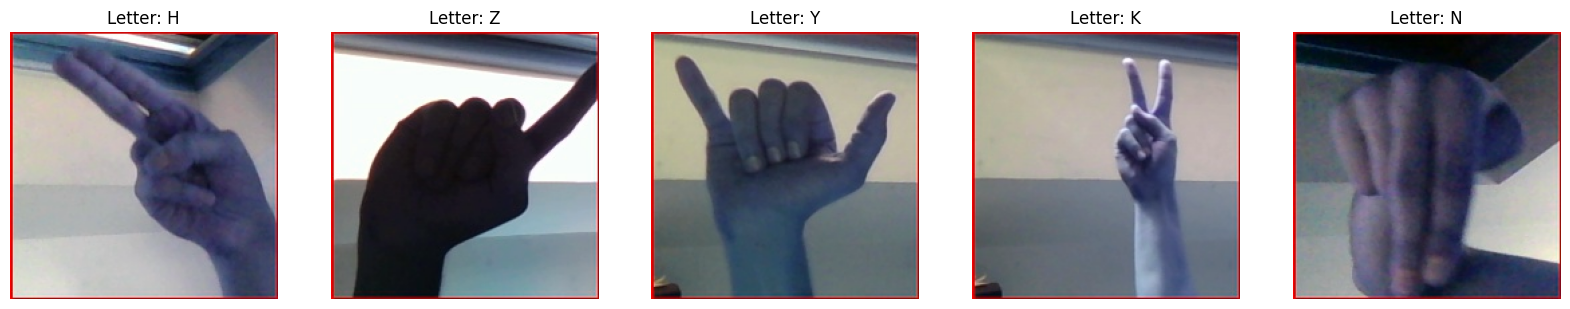

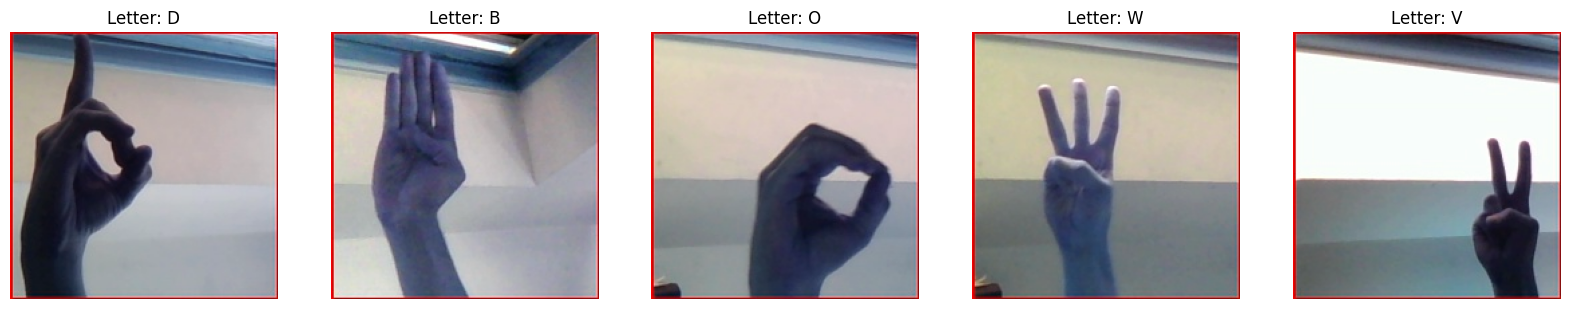

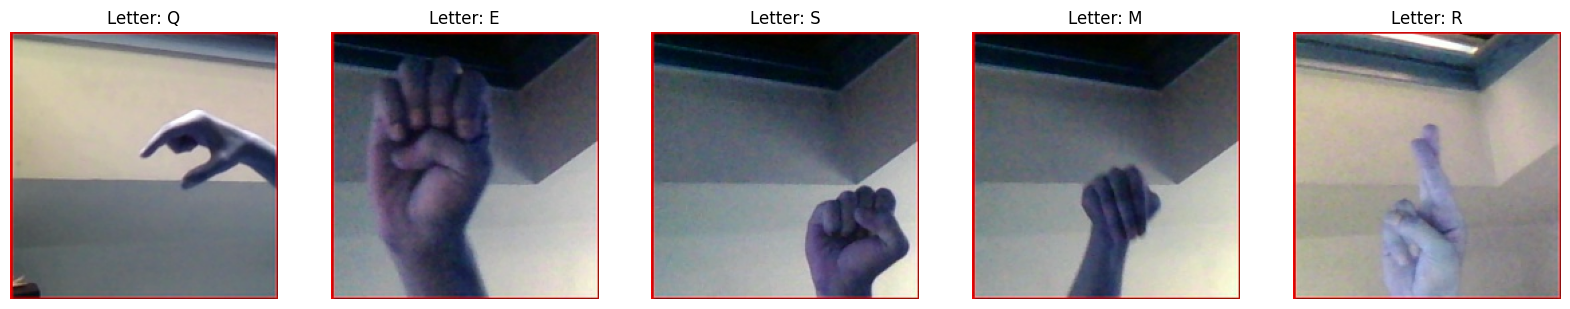

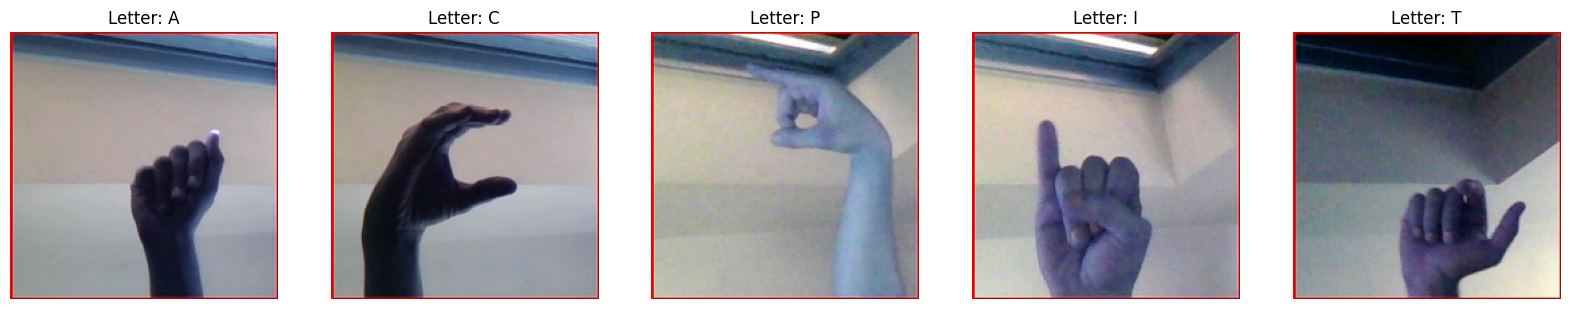

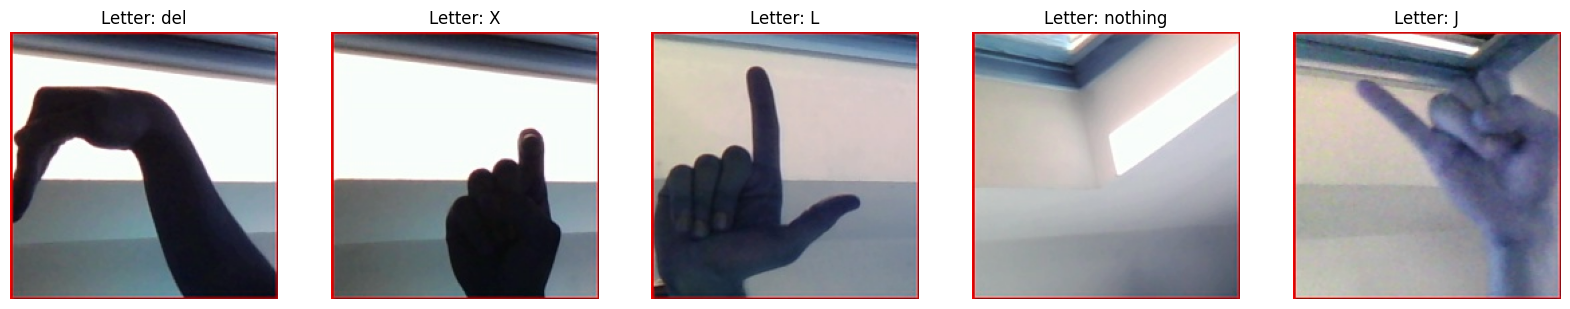

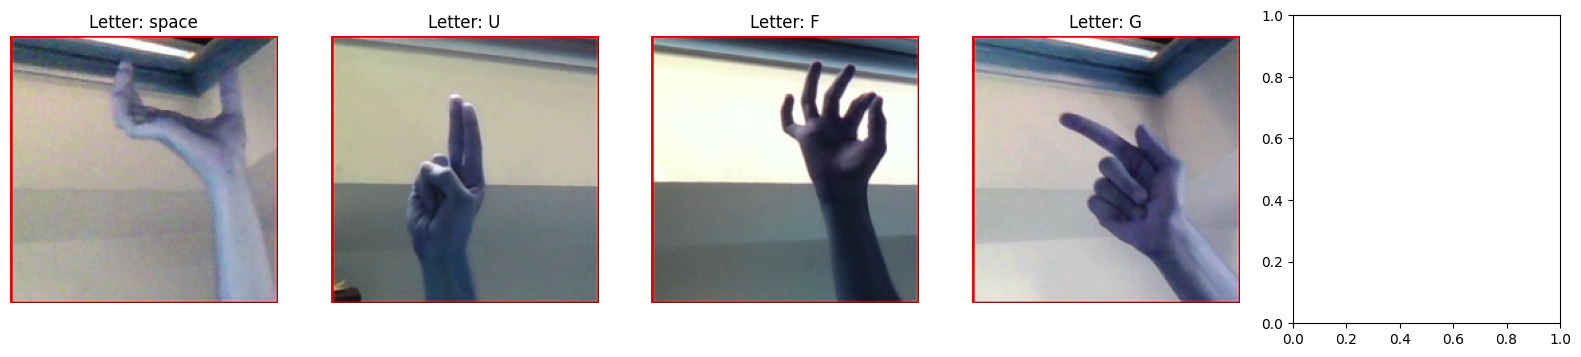

In [8]:
images_per_row = 5
num_images = len(paths)

for i in range(0, num_images, images_per_row):
    fig, axes = plt.subplots(1, images_per_row, figsize=(20, 4))

    for j in range(images_per_row):
        idx = i + j
        if idx < num_images:
            subdir = paths[idx]
            image_files = os.listdir(subdir)
            if image_files:
                image_path = os.path.join(subdir, image_files[0])
                image = cv2.imread(image_path)
                folder_name = os.path.basename(subdir)

                axes[j].imshow(image)
                axes[j].set_title(f'Letter: {folder_name}')
                axes[j].axis('off')

    plt.show()

In [9]:
files_path = []
files_labels = []

for root, dirs, files in os.walk(data_path):
    p = pathlib.Path(root)

    for file in files:
        files_path.append(root + '/' + file)
        files_labels.append(p.parts[-1])

len(files_path), len(files_labels)

(87000, 87000)

In [10]:
import pandas as pd

df = pd.DataFrame(list(zip(files_labels,files_path)),
               columns =['labels', 'image'])
df.head()

,labels,image
0,H,/content/asl-alphabet/asl_alphabet_train/asl_a...
1,H,/content/asl-alphabet/asl_alphabet_train/asl_a...
2,H,/content/asl-alphabet/asl_alphabet_train/asl_a...
3,H,/content/asl-alphabet/asl_alphabet_train/asl_a...
4,H,/content/asl-alphabet/asl_alphabet_train/asl_a...


In [11]:
x_train,x_test = train_test_split(df, test_size= 0.2, random_state=42)

H 3000
Z 3000
Y 3000
K 3000
N 3000
D 3000
B 3000
O 3000
W 3000
V 3000
Q 3000
E 3000
S 3000
M 3000
R 3000
A 3000
C 3000
P 3000
I 3000
T 3000
del 3000
X 3000
L 3000
nothing 3000
J 3000
space 3000
U 3000
F 3000
G 3000


<BarContainer object of 29 artists>

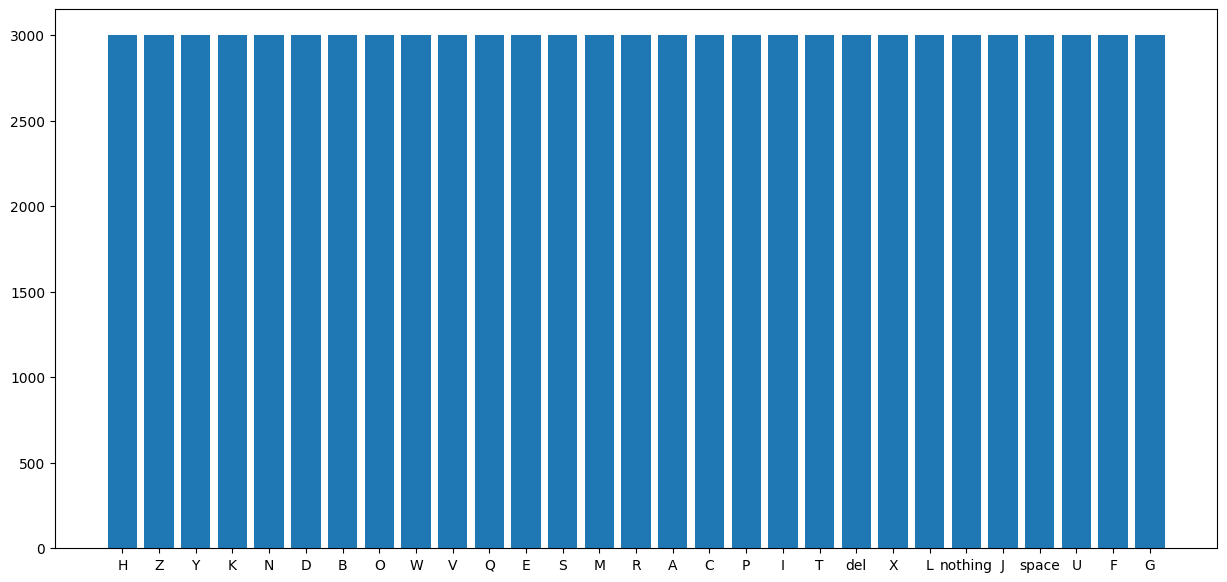

In [12]:
label_count = []
for label in labell:
  print(label, files_labels.count(label))
  label_count.append(files_labels.count(label))

#Plotting a label vs label_count graph.
plt.figure(figsize=(15, 7))
plt.bar(labell, label_count)

In [13]:
batch_size = 300
image_size = (100, 100)
x_column = 'image'
y_column = 'labels'

In [14]:
# Create a data generator with data augmentation and splitting
data_generator = ImageDataGenerator(
    rescale=1.0 / 255,  # Rescale pixel values to [0, 1]
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
)

In [15]:
data_generator_flow = data_generator.flow_from_dataframe(
    x_train,
    x_col = x_column,
    y_col = y_column,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    color_mode = 'grayscale',
    shuffle=False,
)

Found 69600 validated image filenames belonging to 29 classes.


In [16]:
validation_generator_flow = data_generator.flow_from_dataframe(
    x_test,
    x_col = x_column,
    y_col = y_column,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    color_mode = 'grayscale',
    shuffle=False,
)

Found 17400 validated image filenames belonging to 29 classes.


In [17]:
model = Sequential()
model.add(Conv2D(64, (5, 5), activation='relu', input_shape=(100, 100, 1)))
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(.2))
model.add(Conv2D(128, (5, 5), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(.2))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(.2))
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(.5))
model.add(Dense(29, activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 44, 44, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     6,554,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │        14,877 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,923,165 (26.41 MB)

 Trainable params: 6,923,165 (26.41 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(optimizer= Adam(learning_rate=.001), loss='categorical_crossentropy', metrics=['accuracy'])

In [21]:
early_stopping_callback = EarlyStopping(
    monitor='val_accuracy',
    patience=3
)
tensorboard_callback = TensorBoard(
    log_dir='logs',
    histogram_freq=1
)
model_checkpoint_callback = ModelCheckpoint('best_model.h5',
                                            monitor='val_loss', save_best_only=True)

In [23]:
model.fit(data_generator_flow,
          epochs = 15,
          validation_data = validation_generator_flow,
          callbacks =[early_stopping_callback,
                      tensorboard_callback,
                      model_checkpoint_callback]
          )

Epoch 1/15
232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 592ms/step - accuracy: 0.1159 - loss: 3.0672

232/232 ━━━━━━━━━━━━━━━━━━━━ 179s 772ms/step - accuracy: 0.2392 - loss: 2.5809 - val_accuracy: 0.5664 - val_loss: 1.4811
Epoch 2/15
232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 608ms/step - accuracy: 0.5419 - loss: 1.4333

232/232 ━━━━━━━━━━━━━━━━━━━━ 174s 749ms/step - accuracy: 0.5952 - loss: 1.2578 - val_accuracy: 0.7924 - val_loss: 0.7023
Epoch 3/15
232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 576ms/step - accuracy: 0.7186 - loss: 0.8666

232/232 ━━━━━━━━━━━━━━━━━━━━ 167s 718ms/step - accuracy: 0.7337 - loss: 0.8145 - val_accuracy: 0.8581 - val_loss: 0.4817
Epoch 4/15
232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 573ms/step - accuracy: 0.7902 - loss: 0.6331

232/232 ━━━━━━━━━━━━━━━━━━━━ 166s 715ms/step - accuracy: 0.8002 - loss: 0.6018 - val_accuracy: 0.9038 - val_loss: 0.3206
Epoch 5/15
232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 570ms/step - accuracy: 0.8338 - loss: 0.4986

...

232/232 ━━━━━━━━━━━━━━━━━━━━ 164s 708ms/step - accuracy: 0.9197 - loss: 0.2387 - val_accuracy: 0.9771 - val_loss: 0.0886
Epoch 11/15
232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 578ms/step - accuracy: 0.9256 - loss: 0.2211

232/232 ━━━━━━━━━━━━━━━━━━━━ 166s 716ms/step - accuracy: 0.9280 - loss: 0.2135 - val_accuracy: 0.9761 - val_loss: 0.0810
Epoch 12/15
232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 572ms/step - accuracy: 0.9311 - loss: 0.2038

232/232 ━━━━━━━━━━━━━━━━━━━━ 165s 712ms/step - accuracy: 0.9345 - loss: 0.1936 - val_accuracy: 0.9834 - val_loss: 0.0637
Epoch 13/15
232/232 ━━━━━━━━━━━━━━━━━━━━ 164s 705ms/step - accuracy: 0.9400 - loss: 0.1753 - val_accuracy: 0.9754 - val_loss: 0.0772
Epoch 14/15
232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 574ms/step - accuracy: 0.9408 - loss: 0.1756

232/232 ━━━━━━━━━━━━━━━━━━━━ 165s 711ms/step - accuracy: 0.9428 - loss: 0.1688 - val_accuracy: 0.9876 - val_loss: 0.0472
Epoch 15/15
232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 575ms/step - accuracy: 0.9466 - loss: 0.1580

232/232 ━━━━━━━━━━━━━━━━━━━━ 166s 714ms/step - accuracy: 0.9460 - loss: 0.1594 - val_accuracy: 0.9878 - val_loss: 0.0447


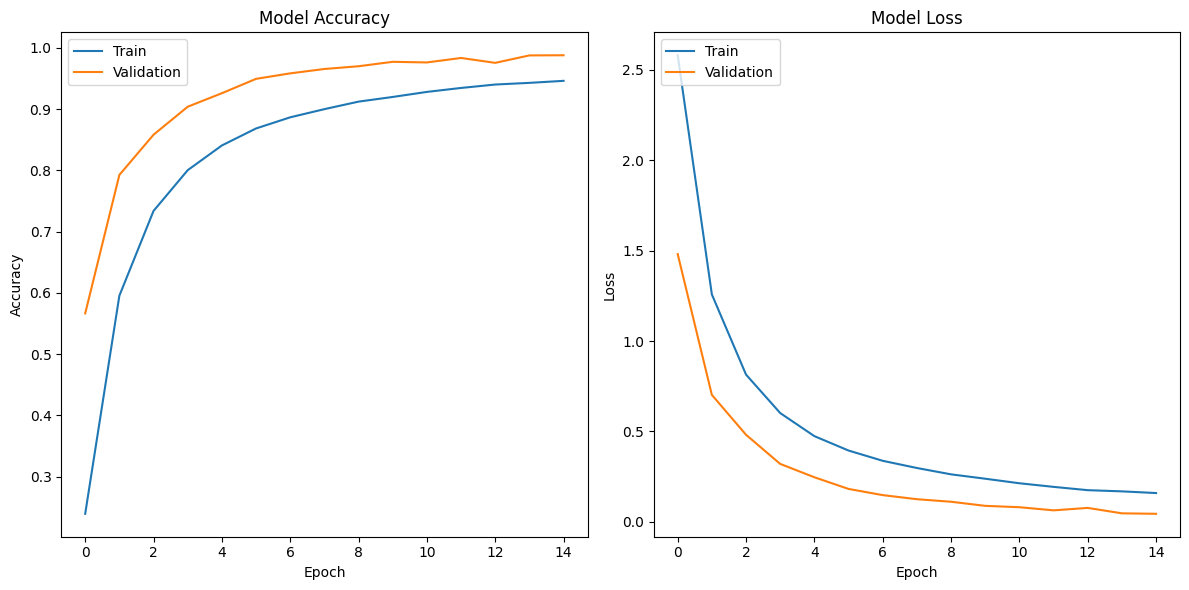

In [24]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [25]:
# Generate predictions on the validation data
predictions = model.predict(validation_generator_flow)

# Get true labels from the validation generator
true_labels = validation_generator_flow.classes

# Get predicted labels by taking the argmax of the predictions
predicted_labels = np.argmax(predictions, axis=1)

# Get the class names from the generator
class_names = list(validation_generator_flow.class_indices.keys())

print(f"Number of validation samples: {len(true_labels)}")
print(f"First 5 true labels: {true_labels[:5]}")
print(f"First 5 predicted labels: {predicted_labels[:5]}")

58/58 ━━━━━━━━━━━━━━━━━━━━ 32s 529ms/step
Number of validation samples: 17400
First 5 true labels: [19, 21, 4, 23, 15]
First 5 predicted labels: [19 21  4 23 15]


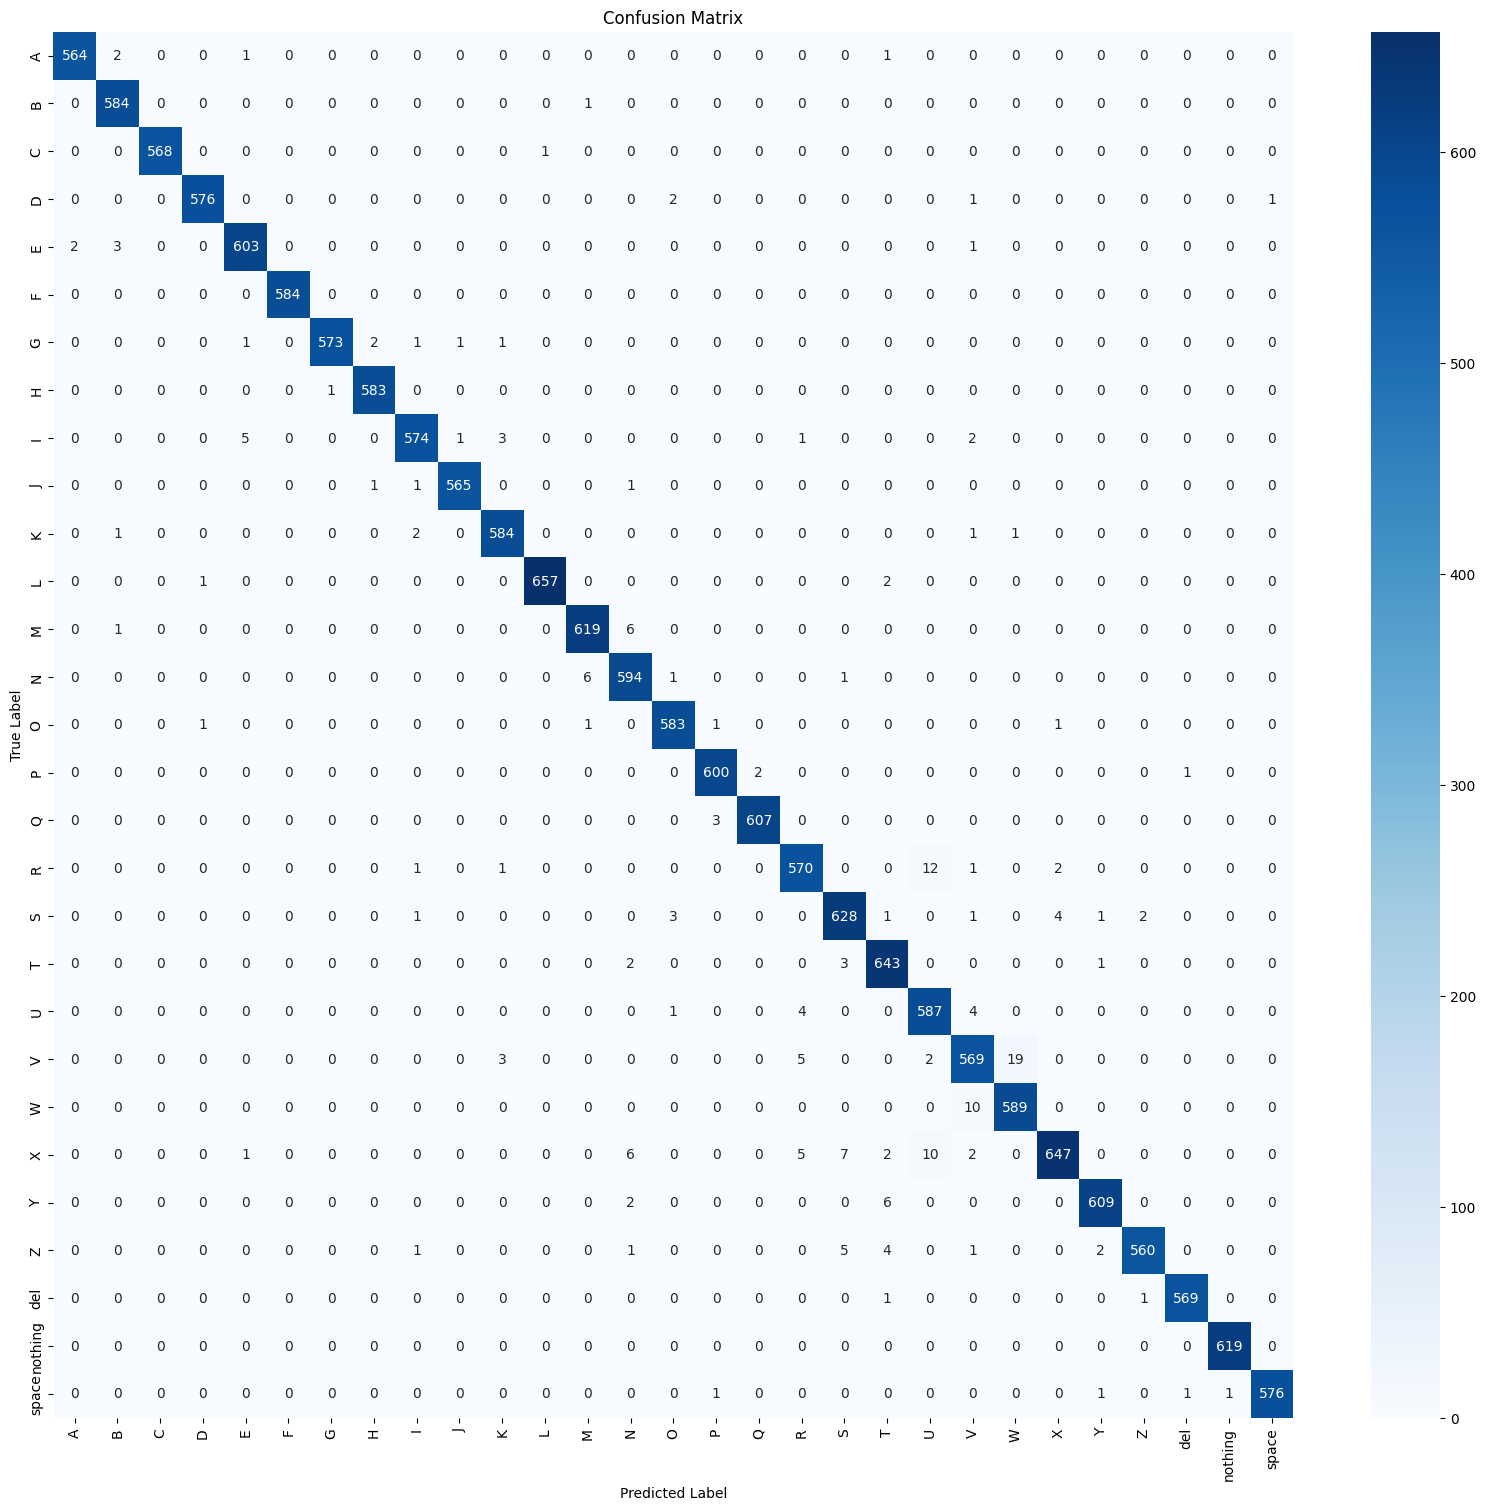

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Compute the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix
plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()